In [1]:
from nugets.models import BackBone, Model
from nugets.models.backbones.transformer import Transformer
from nugets.models.backbones.sumformer import Sumformer
from nugets.tasks.set_membership_tasks import ConvexHullMembershipTask
import torch

/home/sam/anaconda3/envs/nugets/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/usr/bin/ld: cannot find -lnvrtc: No such file or directory
collect2: error: ld returned 1 exit status

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] Warning : There were warnings or errors :
/usr/bin/ld: cannot find -lnvrtc: No such file or directory
collect2: error: ld returned 1 exit status

OK


In [3]:
task = ConvexHullMembershipTask(dataset='SQUIDBoundaries', 
                                dataset_parameters=dict(normalization=True), 
                                ood_dataset_name='SQUIDBoundaries', 
                                ood_dataset_parameters=dict(normalization=True))
backbone: BackBone = Sumformer(aggregation='none',
                               feed_forward_hidden_dim=64,
                               n_layers=3, 
                               d_model=16, 
                               layer_norm_eps=0.001)
model = Model(backbone, task, 
              batch_size=32, 
              learning_rate=1e-4, 
              debug_mode=True, 
              loss_function='scatter_binary_focal_loss')
model = model.to(dtype=torch.float32)

In [65]:
transformer_backbone: BackBone = Transformer(n_heads=1, 
                                             n_layers=3, 
                                             d_model=16, 
                                             feed_forward_hidden_dim=64, 
                                             aggregation='none')
model_tf = Model(transformer_backbone, task, 
                 batch_size=32, 
                 learning_rate=1e-4, 
                 debug_mode=True, 
                 loss_function='scatter_binary_focal_loss', 
                 positional_encoding=None)
model_tf = model_tf.to(dtype=torch.float32)

In [67]:
tf_pth = 'workdir/models/uAH0Y4vQIOZIaxAKeZzs:31wmCGsF39hkKiGVeRFOIk=/last.ckpt'
ckpt = torch.load(tf_pth)
model_tf.load_state_dict(ckpt['state_dict'])
model_tf.eval()

Model(
  (backbone): Transformer(
    (transformer): Transformer(
      (attention_0): TransformerBlock(
        (layer_norm): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
        (self_attention): SelfAttention(
          (query_key_value): Linear(in_features=16, out_features=48, bias=True)
          (out_proj): Linear(in_features=16, out_features=16, bias=True)
        )
      )
      (feed_forward_0): TransformerFeedForwardBlock(
        (layer_norm): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (linear_0): Linear(in_features=16, out_features=64, bias=True)
          (activation_0): ReLU()
          (linear_1): Linear(in_features=64, out_features=64, bias=True)
          (activation_1): ReLU()
          (linear_2): Linear(in_features=64, out_features=16, bias=True)
        )
      )
      (attention_1): TransformerBlock(
        (layer_norm): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
        (self_attention): SelfAttention(
  

In [5]:
import os

os.path.exists(f'workdir/models/zPfv-q:eSQlf21YIbwcgBNSeD4VkGdjgJRt-rOe4e7s=/last.ckpt')
model_pth = 'workdir/models/zPfv-q:eSQlf21YIbwcgBNSeD4VkGdjgJRt-rOe4e7s=/last.ckpt'
ckpt = torch.load(model_pth)
model.load_state_dict(ckpt['state_dict'])
model.eval()

Model(
  (backbone): Sumformer(
    (sumformer): Sumformer(
      (0): SumformerBlock(
        (block): SumformerInnerBlock(
          (global_embedding): GlobalEmbedding(
            (mlp): MLP(
              (linear_0): Linear(in_features=16, out_features=64, bias=True)
              (activation_0): LeakyReLU(negative_slope=0.01)
              (linear_1): Linear(in_features=64, out_features=64, bias=True)
              (activation_1): LeakyReLU(negative_slope=0.01)
              (linear_2): Linear(in_features=64, out_features=64, bias=True)
              (activation_2): LeakyReLU(negative_slope=0.01)
              (linear_3): Linear(in_features=64, out_features=256, bias=True)
            )
            (activation): LeakyReLU(negative_slope=0.01)
            (aggregation): MeanAggregation()
          )
          (input_linear): Linear(in_features=16, out_features=64, bias=True)
          (aggreg_linear): Linear(in_features=256, out_features=64, bias=True)
          (psi): MLP(
      

In [68]:
models = [model, model_tf]

In [6]:
model.prepare_data()

In [40]:
from nugets.pipeline.configs import Config
from pathlib import Path
cfg_pth = Path('config.yaml')
Config.load(cfg_pth)
config = Config.get()
val = model.val_dataloader()

val dataset size: 110
ood dataset size: 110


In [42]:
validation = val[0]

In [69]:
from tqdm import tqdm
all_model_outputs =[]
for m in models: 
    model_outputs = []
    ground_truth_ptset = []
    ground_truth_labels = []
    for batch in tqdm(validation):
        raw_model_output = m(batch)
        start = 0
        for num in raw_model_output.n_nodes:
            end = start + num
            single_model_output = raw_model_output.data[start:end]
            ptset = batch.pointset.data[start:end]
            label = batch.labelset.data[start:end]

            model_outputs.append(single_model_output.detach().squeeze())
            ground_truth_ptset.append(ptset.numpy())
            ground_truth_labels.append(label.numpy().squeeze())
    all_model_outputs.append(model_outputs)

100%|██████████████████████████████████████████████████████████████████████████████| 4/4 [01:22<00:00, 20.74s/it]


In [70]:
def compute_metrics(predicted, target):
    """
    Return recall, precision, and f1 score
    """
    tn_mask = target == 0
    tp_mask = target == 1
    
    tps = np.sum(predicted[tp_mask] == 1)
    fns = np.sum(predicted[tp_mask] == 0)
    fps = np.sum(predicted[tn_mask] == 1)
    
    recall = tps/(tps + fns)
    precision = tps/(tps + fps + 1e-5)
    f1 = 2 * (recall * precision)/(recall+precision + 1e-5)
    return recall, precision, f1

In [71]:
from tqdm import tqdm 
import numpy as np

thresh = 0.3
threshholds = [0.2, 0.25, 0.30, 0.35, 0.40, 0.45, 0.5, 0.55]
model_metrics = []
for model_outputs in all_model_outputs:
    metric_dict = {'recall':[], 'acc': [], 'precision': [], 'f1': []}

    for t in tqdm(threshholds): 
        recalls = []
        accs = []
        precisions = []
        f1 = []
        for i in range(len(model_outputs)):
            logits = model_outputs[i]
            expits = torch.sigmoid(logits).numpy()
            predicted = (expits >= t)
            target = ground_truth_labels[i]

            correct = (predicted == target)
            accs.append(np.sum(correct)/len(correct))

            r, p, f1_ = compute_metrics(predicted, target)


            recalls.append(r)
            precisions.append(p)

            f1.append(f1_)

        metric_dict['recall'].append(recalls)
        metric_dict['acc'].append(accs)
        metric_dict['precision'].append(precisions)
        metric_dict['f1'].append(f1)
    model_metrics.append(metric_dict)

100%|██████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 10.61it/s]


In [72]:
for metric_dict in model_metrics:
    for key in metric_dict:
        metric_dict[key] = np.array(metric_dict[key])

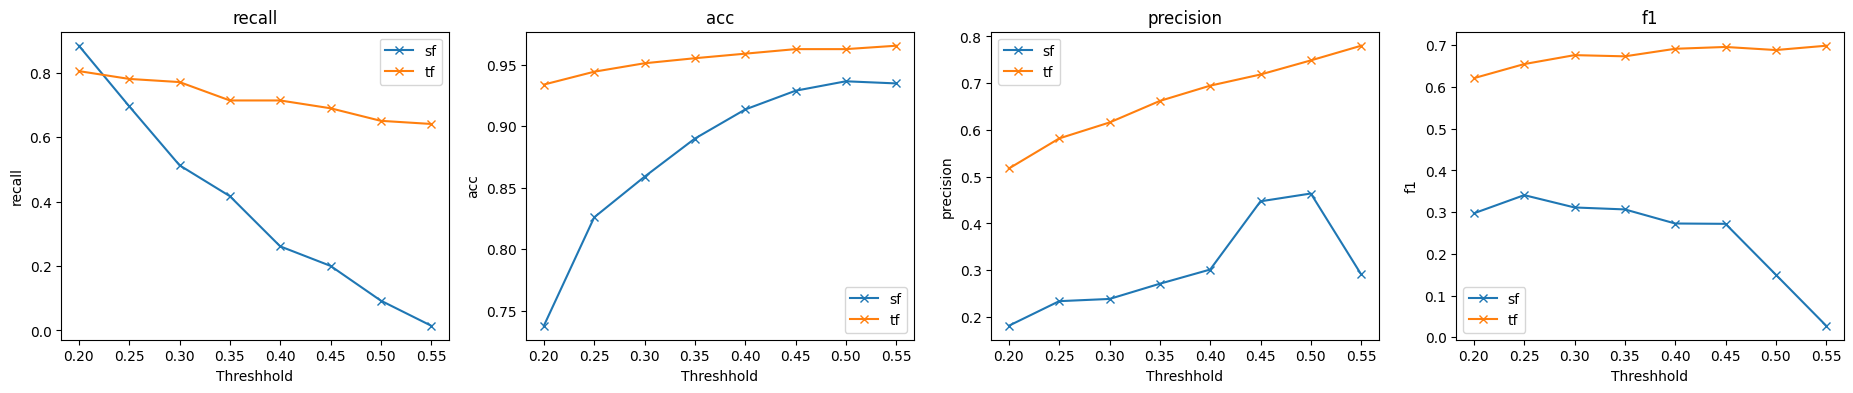

In [74]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 4, figsize=(23, 4))
keys = ['recall', 'acc', 'precision', 'f1']
labels = ['sf', 'tf']
for i in range(4):
    for k in range(2):
        axs[i].plot(threshholds, np.mean(model_metrics[k][keys[i]], axis=1), marker='x', label=labels[k])
        axs[i].set_title(keys[i])
        axs[i].set_xlabel('Threshhold')
        axs[i].set_ylabel(keys[i])
        axs[i].legend()